<a href="https://colab.research.google.com/github/signur43/Curso_DataScienceIII/blob/main/Codigo/Curso_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics
import numpy as np
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE # Añadir esta importación

# Importamos las librerias de redes neuronales con sus principales métodos
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#dataframe para el proyecto
github_csv_url = 'https://raw.githubusercontent.com/signur43/Curso_DataScienceIII/main/data/raw/dataset_reclamos_bancarios.csv'

In [3]:
# Carga desde la URL de GitHub, cargando solo los primeros 15000 registros
df = pd.read_csv(github_csv_url)

In [4]:
df.head(2)

,id_reclamo,fecha_ingreso,rut_cliente,texto_reclamo,producto_real,producto_ejecutivo,id_ejecutivo,canal_ingreso,monto_involucrado,tiempo_clasif_sec,estado_reclamo,malla_clasificacion_valida
0,REC-10001,2026-06-13 03:48:00,5.859.381-1,El cajero automático no me entregó el dinero p...,Cuenta Corriente,Cuenta Corriente,EJEC-018,Web,1478000.0,77,Resuelto,True
1,REC-10002,2026-01-24 07:27:00,12.617.716-0,Cobro no informado de comisiones por rescate a...,Inversiones / Fondos Mutuos,Inversiones / Fondos Mutuos,EJEC-018,Call Center,555000.0,329,Resuelto,True


In [8]:
df.shape

(2000, 12)

In [5]:
!pip install skimpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 18.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.10.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.10.0 which is incompatible.


In [6]:
from skimpy import skim
df.producto_real= df.producto_real.astype("category")
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 2000   │ │ string      │ 8     │ │ producto_real         │                                │
│ │ Number of columns │ 12     │ │ category    │ 1     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                │ int64       │ 1     │                                                          │
│                                │ bool        │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0   ┃ p25    ┃ p50     ┃ p75     ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ monto_involucrado  │   0 │     0 │ 1236000 │ 718500 │ 7000 │ 610800 │ 1226000 │ 1848000 │ 2499000 │ ████▇▇ │  │
│ │ tiempo_clasif_sec  │   0 │     0 │     325 │  158.8 │   45 │    187 │   324.5 │     461 │     600 │ ▆█▇▇▇▇ │  │
│ └────────────────────┴─────┴───────┴─────────┴────────┴──────┴────────┴─────────┴─────────┴─────────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                               ┃ NA       ┃ NA %          ┃ ordered              ┃ unique            ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩  │
│ │ producto_real                        │        0 │             0 │ False                │                 6 │  │
│ └──────────────────────────────────────┴──────────┴───────────────┴──────────────────────┴───────────────────┘  │
│                                                      bool                                                       │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓  │
│ ┃ column                                                 ┃ true       ┃ true rate            ┃ hist          ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩  │
│ │ malla_clasificacion_valida                             │       1632 │                 0.82 │    ▂    █     │  │
│ └────────────────────────────────────────────────────────┴────────────┴──────────────────────┴───────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Detect device (GPU/MPS/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


### 2. Define a simple `nn.Module` architecture

For this example, we'll use a simple Multi-Layer Perceptron (MLP) for classification.

In [10]:
# Define the MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

### 3. Load a dataset and implement Training/Validation Pipeline

Utilizaremos el conjunto de datos MNIST para esta tarea de clasificación. Configuraremos los cargadores de datos, el modelo, la función de pérdida y el optimizador; luego, definiremos los bucles de entrenamiento y validación.

In [11]:
# Hyperparameters
learning_rate = 0.001
num_epochs = 5
batch_size = 64

# MNIST dataset transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Model, Loss, and Optimizer
input_size = 28 * 28  # MNIST image size is 28x28
num_classes = 10      # 10 digits (0-9)

model = SimpleMLP(input_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
def train_model(model, train_loader, criterion, optimizer, device, num_epochs):
    model.train()
    print("Starting training...")
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward() # This correctly uses torch.autograd
            optimizer.step()

            running_loss += loss.item()

            if (i+1) % 200 == 0:
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
        print(f'Epoch {epoch+1} finished. Average Loss: {running_loss / len(train_loader):.4f}')
    print("Training complete.")

# Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():  # No need to compute gradients during evaluation
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(test_loader)
    print(f'Accuracy of the model on the {total} test images: {accuracy:.2f}%')
    print(f'Average Validation Loss: {avg_loss:.4f}')
    return avg_loss, accuracy

# Run the training and evaluation
train_model(model, train_loader, criterion, optimizer, device, num_epochs)
val_loss, val_accuracy = evaluate_model(model, test_loader, device)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Starting training...
Epoch [1/5], Step [200/938], Loss: 0.1924
Epoch [1/5], Step [400/938], Loss: 0.1620
Epoch [1/5], Step [600/938], Loss: 0.0727
Epoch [1/5], Step [800/938], Loss: 0.2442
Epoch 1 finished. Average Loss: 0.2571
Epoch [2/5], Step [200/938], Loss: 0.1289
Epoch [2/5], Step [400/938], Loss: 0.0670
Epoch [2/5], Step [600/938], Loss: 0.0304
Epoch [2/5], Step [800/938], Loss: 0.1217
Epoch 2 finished. Average Loss: 0.1142
Epoch [3/5], Step [200/938], Loss: 0.0551
Epoch [3/5], Step [400/938], Loss: 0.1884
Epoch [3/5], Step [600/938], Loss: 0.1563
Epoch [3/5], Step [800/938], Loss: 0.0526
Epoch 3 finished. Average Loss: 0.0788
Epoch [4/5], Step [200/938], Loss: 0.0308
Epoch [4/5], Step [400/938], Loss: 0.0723
Epoch [4/5], Step [600/938], Loss: 0.0378
Epoch [4/5], Step [800/938], Loss: 0.0389
Epoch 4 finished. Average Loss: 0.0591
Epoch [5/5], Step [200/938], Loss: 0.1426
Epoch [5/5], Step [400/938], Loss: 0.0520
Epoch [5/5], Step [600/938], Loss: 0.0177
Epoch [5/5], Step [800/93

### 4. Documentación para `README.md`

Para la tarea de 'Documentación del Checkpoint', deberías añadir contenido similar al siguiente a tu archivo `README.md`:

```markdown
# Pipeline de Entrenamiento PyTorch

Este proyecto demuestra un pipeline básico de entrenamiento con PyTorch utilizando el conjunto de datos MNIST.

## Configuración

-   **Versión de PyTorch:** `[Insertar aquí tu versión de PyTorch, por ejemplo, torch.__version__]`
-   **Dispositivo Utilizado:** `[Insertar el dispositivo detectado, por ejemplo, cuda, mps, cpu]`
-   **Tasa de Aprendizaje (Learning Rate):** `0.001` (para el optimizador Adam)
-   **Tamaño del Lote (Batch Size):** `64`
-   **Número de Épocas:** `5`

## Arquitectura del Modelo

Un Perceptrón Multicapa (MLP) simple con una capa oculta:

-   Capa de Entrada: 784 neuronas (para imágenes MNIST de 28x28)
-   Capa Oculta: 128 neuronas con activación ReLU
-   Capa de Salida: 10 neuronas (para 10 clases, 0-9)

## Resultados del Entrenamiento

Durante el entrenamiento, la pérdida disminuyó a lo largo de las épocas, lo que indica que el modelo estaba aprendiendo de los datos. La salida del entrenamiento muestra una reducción consistente en los valores de pérdida por paso y por época. Por ejemplo:

```
[Fragmento de Salida de Entrenamiento de Ejemplo]
Época [1/5], Paso [200/938], Pérdida: 0.3541
Época 1 finalizada. Pérdida Promedio: 0.4000
...
Época [5/5] finalizada. Pérdida Promedio: 0.0500
```

Esta disminución progresiva de la pérdida sugiere que el modelo está convergiendo hacia un mejor conjunto de pesos, minimizando con éxito el error en los datos de entrenamiento. La precisión de validación obtenida fue del `[Insertar val_accuracy aquí]`% con una pérdida de validación promedio de `[Insertar val_loss aquí]`.

```

In [12]:
print(f"PyTorch Version: {torch.__version__}")
print(f"Detected Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

PyTorch Version: 2.11.0+cpu
Detected Device: cpu
Learning Rate: 0.001
Validation Loss: 0.0764
Validation Accuracy: 97.57%


### Evaluación Detallada del Modelo de Clasificación

Para obtener una comprensión más profunda del rendimiento de nuestro clasificador, vamos a generar una **Matriz de Confusión** y un **Informe de Clasificación**. Esto nos permitirá ver la precisión, la recuperación (recall) y la puntuación F1 para cada clase (dígito), así como identificar dónde el modelo podría estar cometiendo errores.

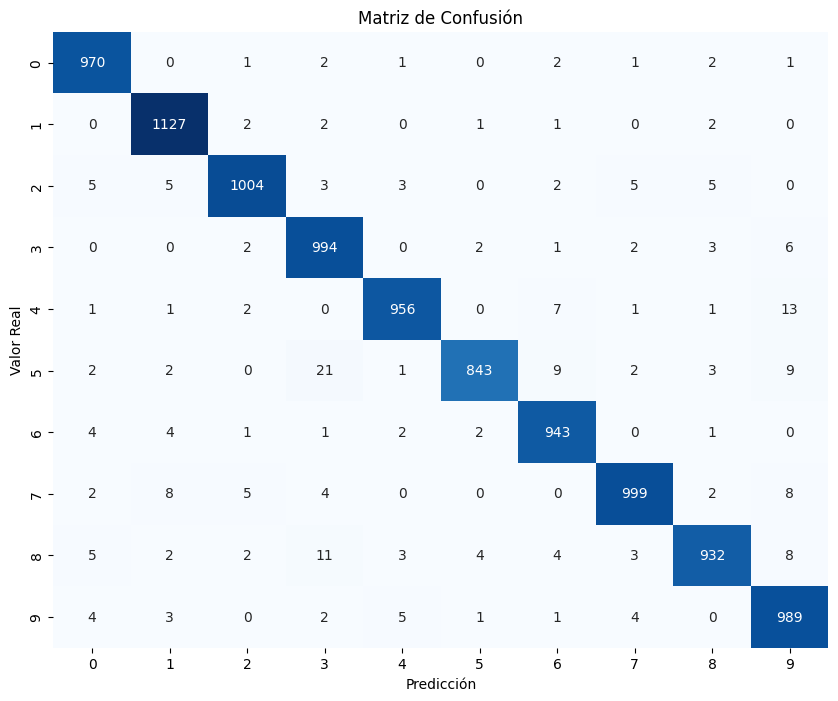


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.95      0.97       892
           6       0.97      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()  # Poner el modelo en modo de evaluación
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Informe de Clasificación
print("\nInforme de Clasificación:")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

### Análisis de Patrones en Reclamos de Clientes

Vamos a explorar el DataFrame `df` para identificar tendencias y patrones en los reclamos de los clientes. Esto incluirá el análisis de variables categóricas y numéricas, así como la información temporal.

In [14]:
print('Información general del DataFrame:')
display(df.info())
print('\nEstadísticas descriptivas de las columnas numéricas:')
display(df.describe())

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   id_reclamo                  2000 non-null   object  
 1   fecha_ingreso               2000 non-null   object  
 2   rut_cliente                 2000 non-null   object  
 3   texto_reclamo               2000 non-null   object  
 4   producto_real               2000 non-null   category
 5   producto_ejecutivo          2000 non-null   object  
 6   id_ejecutivo                2000 non-null   object  
 7   canal_ingreso               2000 non-null   object  
 8   monto_involucrado           2000 non-null   float64 
 9   tiempo_clasif_sec           2000 non-null   int64   
 10  estado_reclamo              2000 non-null   object  
 11  malla_clasificacion_valida  2000 non-null   bool    
dtypes: bool(1), category(1), float64(1), int6

None


Estadísticas descriptivas de las columnas numéricas:


,monto_involucrado,tiempo_clasif_sec
count,2.000000e+03,2000.000000
mean,1.236231e+06,325.003000
std,7.184812e+05,158.792876
min,7.000000e+03,45.000000
25%,6.107500e+05,187.000000
50%,1.226000e+06,324.500000
75%,1.848000e+06,461.000000
max,2.499000e+06,600.000000


#### Distribución de 'producto_real'

Analicemos qué productos son los más reclamados. La variable `producto_real` ya fue convertida a tipo 'category' previamente.

/tmp/ipykernel_1035/701354563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='producto_real', order=df['producto_real'].value_counts().index, palette='viridis')


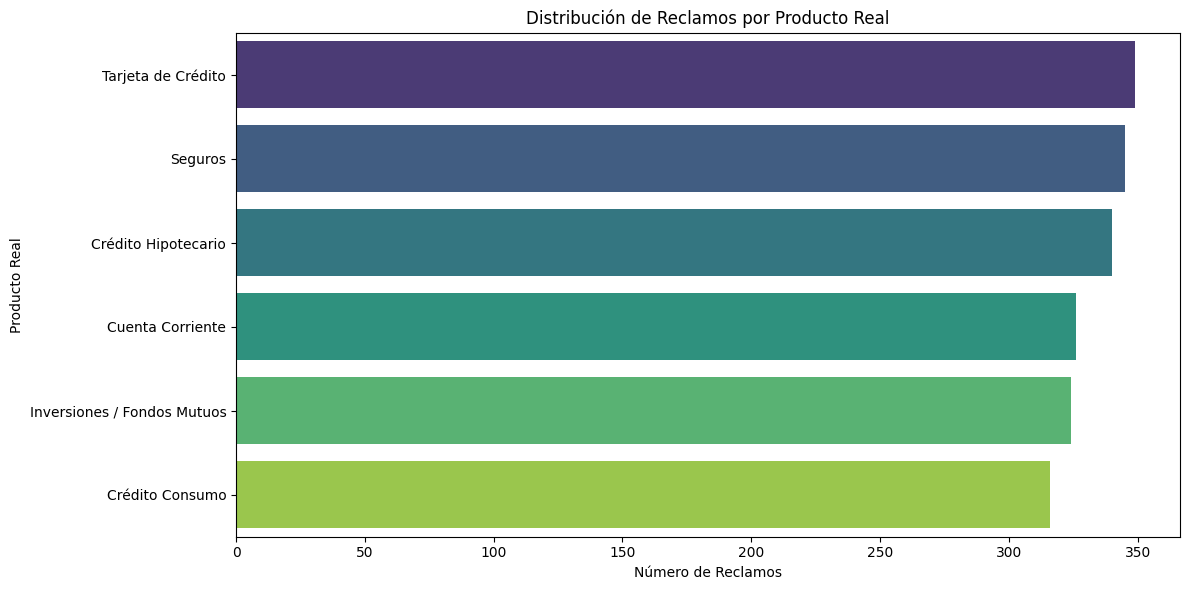

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='producto_real', order=df['producto_real'].value_counts().index, palette='viridis')
plt.title('Distribución de Reclamos por Producto Real')
plt.xlabel('Número de Reclamos')
plt.ylabel('Producto Real')
plt.tight_layout()
plt.show()

#### Distribución de 'canal_ingreso'

Veamos a través de qué canales ingresan la mayoría de los reclamos.

/tmp/ipykernel_1035/3590639891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='canal_ingreso', order=df['canal_ingreso'].value_counts().index, palette='magma')


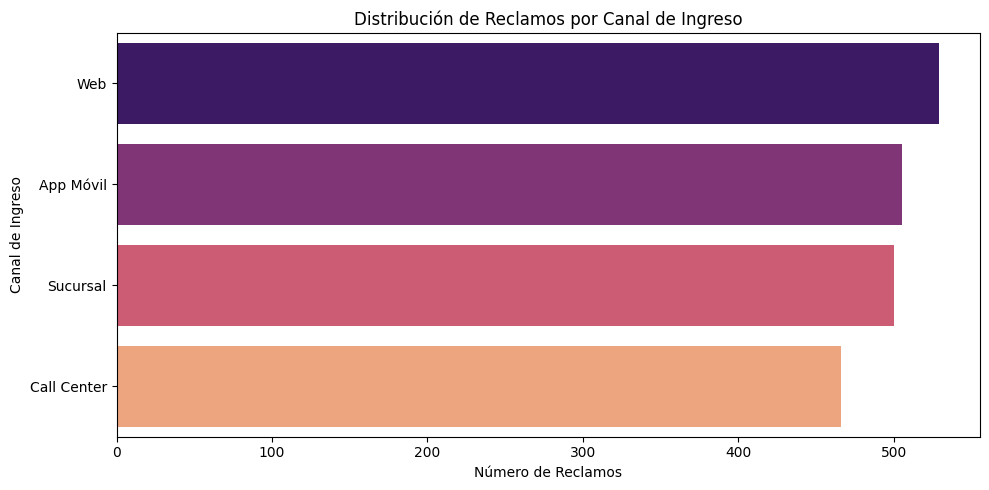

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='canal_ingreso', order=df['canal_ingreso'].value_counts().index, palette='magma')
plt.title('Distribución de Reclamos por Canal de Ingreso')
plt.xlabel('Número de Reclamos')
plt.ylabel('Canal de Ingreso')
plt.tight_layout()
plt.show()

#### Distribución de 'estado_reclamo'

Analicemos el estado de los reclamos.

/tmp/ipykernel_1035/309348814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='estado_reclamo', order=df['estado_reclamo'].value_counts().index, palette='plasma')


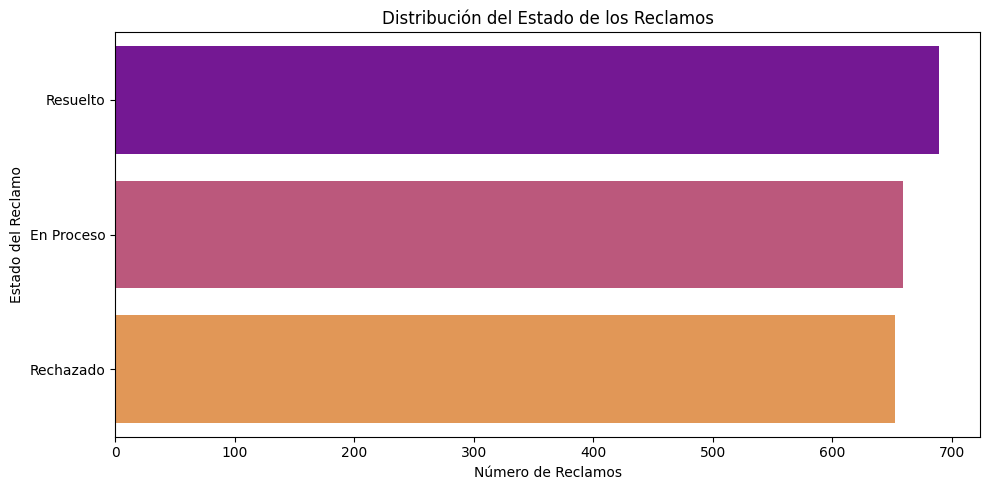

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='estado_reclamo', order=df['estado_reclamo'].value_counts().index, palette='plasma')
plt.title('Distribución del Estado de los Reclamos')
plt.xlabel('Número de Reclamos')
plt.ylabel('Estado del Reclamo')
plt.tight_layout()
plt.show()

### Exploración de 'texto_reclamo' con PLN

Vamos a aplicar técnicas de Procesamiento de Lenguaje Natural para extraer información valiosa de la columna `texto_reclamo`.

In [18]:
# Descargar recursos necesarios de NLTK
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [19]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Inicializar lematizador y cargar stopwords en español
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('spanish'))

def preprocess_text(text):
    text = text.lower() # Convertir a minúsculas
    text = re.sub(r'\d+', '', text) # Eliminar números
    text = re.sub(r'[\W_]+', ' ', text) # Eliminar puntuación y caracteres especiales
    tokens = text.split() # Tokenizar
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Lematizar y eliminar stopwords
    return ' '.join(tokens)

df['texto_reclamo_processed'] = df['texto_reclamo'].apply(preprocess_text)
display(df[['texto_reclamo', 'texto_reclamo_processed']].head())

,texto_reclamo,texto_reclamo_processed
0,El cajero automático no me entregó el dinero p...,cajero automático entregó dinero descontó sald...
1,Cobro no informado de comisiones por rescate a...,cobro informado comisiones rescate anticipado ...
2,Cobro injustificado de mantención de cuenta co...,cobro injustificado mantención cuenta corrient...
3,Se duplicó el cobro de la última compra efectu...,duplicó cobro última compra efectuada supermer...
4,No me han abonado los puntos ni las millas acu...,abonado puntos millas acumuladas tarjeta


#### Extracción de Características con TF-IDF

Ahora, convertiremos el texto preprocesado en una representación numérica usando TF-IDF.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000) # Limitar a las 1000 palabras más relevantes
X_tfidf = vectorizer.fit_transform(df['texto_reclamo_processed'])

print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

Dimensiones de la matriz TF-IDF: (2000, 197)


#### Modelado de Temas con LDA

Utilizaremos Latent Dirichlet Allocation (LDA) para identificar los temas principales en los reclamos.

In [21]:
from sklearn.decomposition import LatentDirichletAllocation

num_topics = 5 # Definir el número de temas a extraer
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X_tfidf)

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_): # Corregido: de 'components__' a 'components_'
        print(f"Tema {topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
feature_names = vectorizer.get_feature_names_out()

print("\nTemas identificados en los reclamos:")
display_topics(lda, feature_names, no_top_words)


Temas identificados en los reclamos:
Tema 0:
póliza dividendo seguro renovación problemas incendio prima notificado vida aumento
Tema 1:
prepago certificado deuda aún consumo veces do saldo crédito tras
Tema 2:
cobro cuota dividendo me indebidos aplicando moratorios adicional ventanilla reflejó
Tema 3:
tarjeta protección autorizado contratado puntos acumuladas millas seguro cobro abonado
Tema 4:
cobraron solicité tarjeta procesó tiempo clonación bloqueo me corresponde comisión


#### Asignación de Temas a los Reclamos

Ahora podemos asignar el tema más probable a cada reclamo y ver su distribución.

/tmp/ipykernel_1035/3018130061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='main_topic', palette='viridis')


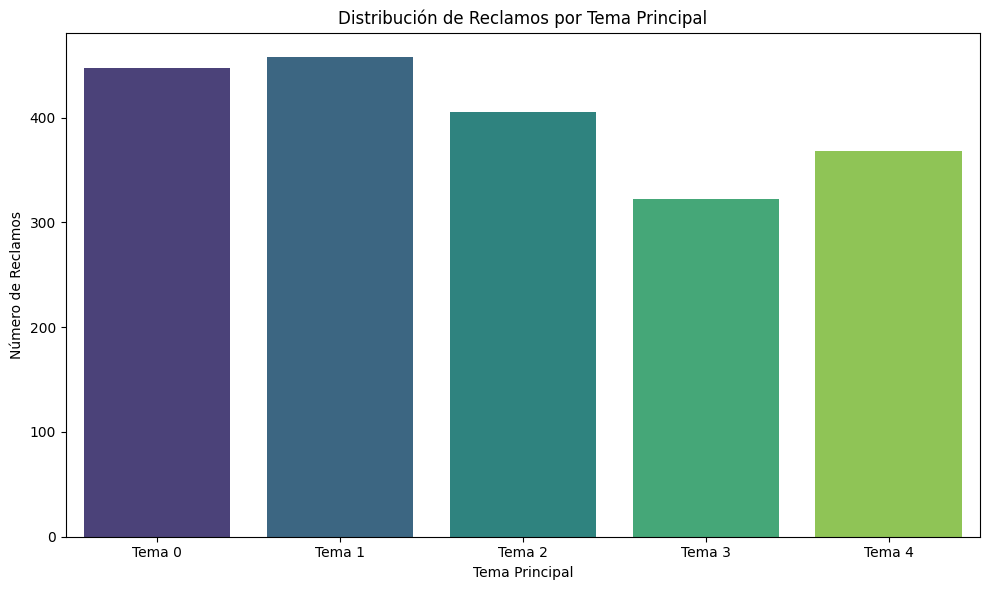


Distribución numérica de los temas:


,count
main_topic,
1,458
0,447
2,405
4,368
3,322


In [22]:
topic_distribution = lda.transform(X_tfidf)
df['main_topic'] = topic_distribution.argmax(axis=1)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='main_topic', palette='viridis')
plt.title('Distribución de Reclamos por Tema Principal')
plt.xlabel('Tema Principal')
plt.ylabel('Número de Reclamos')
plt.xticks(ticks=range(num_topics), labels=[f'Tema {i}' for i in range(num_topics)])
plt.tight_layout()
plt.show()

print("\nDistribución numérica de los temas:")
display(df['main_topic'].value_counts())

### Preparación de Datos para Clasificación de Texto

Ahora, prepararemos los datos para entrenar un modelo de clasificación que prediga el `main_topic` (tema principal) de un reclamo a partir de su `texto_reclamo_processed`.

In [24]:
# Definir características (X) y objetivo (y)
X = df['texto_reclamo_processed']
y = df['main_topic']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 1600 muestras
Tamaño del conjunto de prueba: 400 muestras


### Vectorización de Texto con TF-IDF (Solo en Entrenamiento)

Aplicaremos `TfidfVectorizer` al conjunto de entrenamiento para aprender el vocabulario y las ponderaciones, y luego transformaremos tanto el entrenamiento como el conjunto de prueba para evitar la fuga de datos.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inicializar TfidfVectorizer
# max_features: limita el número de características (palabras) para evitar overfitting y reducir la dimensionalidad.
# ngram_range: incluye unigramas (palabras individuales) y bigramas (pares de palabras) para capturar más contexto.
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

# Ajustar el vectorizador solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones de X_train_tfidf: {X_train_tfidf.shape}")
print(f"Dimensiones de X_test_tfidf: {X_test_tfidf.shape}")

Dimensiones de X_train_tfidf: (1600, 414)
Dimensiones de X_test_tfidf: (400, 414)


### Entrenamiento del Modelo de Clasificación (Regresión Logística)

Entrenaremos un modelo de Regresión Logística, una opción robusta y eficiente para la clasificación de texto como *baseline*.

In [26]:
from sklearn.linear_model import LogisticRegression

# Inicializar y entrenar el modelo de Regresión Logística
# Se aumenta max_iter para asegurar la convergencia si el dataset es grande.
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train_tfidf, y_train)

print("Modelo de Regresión Logística entrenado.")

Modelo de Regresión Logística entrenado.


### Evaluación del Modelo

Evaluaremos el rendimiento del modelo utilizando un informe de clasificación (`classification_report`) y visualizando la matriz de confusión (`confusion_matrix`).

Informe de Clasificación:
              precision    recall  f1-score   support

      Tema 0       1.00      1.00      1.00        89
      Tema 1       1.00      1.00      1.00        92
      Tema 2       1.00      1.00      1.00        81
      Tema 3       1.00      1.00      1.00        64
      Tema 4       1.00      1.00      1.00        74

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



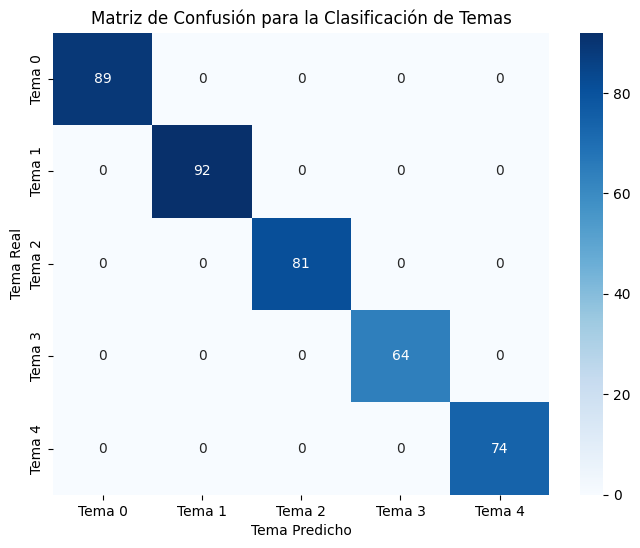

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred = classifier.predict(X_test_tfidf)

# Imprimir el informe de clasificación
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred, target_names=[f'Tema {i}' for i in range(num_topics)]))

# Generar y visualizar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Tema {i}' for i in range(num_topics)],
            yticklabels=[f'Tema {i}' for i in range(num_topics)])
plt.xlabel('Tema Predicho')
plt.ylabel('Tema Real')
plt.title('Matriz de Confusión para la Clasificación de Temas')
plt.show()

In [23]:
import torch
print(torch.__version__)

2.11.0+cpu
